# mask + prepare images for AutoProf + run Autoprof

> Optionally mask sources in a Euclid or Mock image prior to ICL measurements.

> Set NaN values to finite value (default 99), as cleaned images, to prep for autoprof

> Run Autoprof on images, using the measurement mask from step one.

> Extract Surface Brightness Profile with measuring median within annuli, and compare to Autoprof resutls.

In [16]:
# | default_exp euclid.mask

In [17]:
# | exporti

import glob
import re
from pathlib import Path
from typing import Union
import logging
import sys
import os
import traceback
from textwrap import dedent

import importlib.util

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.colors import Normalize
from matplotlib.patches import Ellipse, Circle

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import CCDData
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.stats import sigma_clip


from photutils.aperture import CircularAnnulus, EllipticalAnnulus
from photutils.utils import calc_total_error

from scipy.stats import median_abs_deviation

from nicl.mask import (
    create_bcg_mask,
    create_icl_mask,
    create_faint_mask,
    create_object_mask,
)

from nicl.utilities import (
    calc_sb_threshold as _calc_sb_threshold,
    get_pixel_scale,
    sb_to_adu,
)

from nicl.background import get_background, plot_background
from nicl.main import configure_logging
from nicl.mask import plot_mask

import autoprof
from autoprof import Pipeline

h = 0.7
cosmo = FlatLambdaCDM(H0=h*100, Om0=0.3)

In [18]:
# | exporti
plt.style.use("nicl.euclid.v1nicl")

### masking is too sensitive to NSIGMA in icl mask


In [19]:
######### Parameters below are being called in create_masks
ICL_NSIGMA = 0.5    
ICL_SMOOTH_SIGMA = 50.0
ICL_BKG_BOX_SIZE = 500
ICL_BKG_FILTER_SIZE = 3
ICL_DILATION_RADIUS = 150.0
ICL_MEDIAN_FILTER = True
REGULAR_DETECTION_PARAMS = {
    "nsigma": 3.0,
    "background": 0.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 32,
    "contrast": 0.01,
    "bkg_box_size": 200,
    "bkg_filter_size": 3,
}
REGULAR_GROWTH = 1
FAINT_DETECTION_PARAMS = {
    "nsigma": 2.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 128,
    "contrast": 0.001,
}
FAINT_GROWTH = 0.25
FAINT_BKG_SIGMA = 50.0
NIR_STACK_BKG_BOX_SIZE = 500
NIR_STACK_BKG_FILTER_SIZE = 3

In [20]:

def calc_sb_threshold(
    z,  # cluster redshift
    filter,  # Euclid filter: VIS, Y, J or H
):
    """Determine the ICL surface brightness threshold for a given redshift and Euclid filter."""
    filter = filter.replace("NIR_", "")
    filter = f"Euclid-{filter}.ecsv"
    return _calc_sb_threshold(z, filter)
    
def create_masks(
    image,  # the image to mask, with bad pixels set to NaN, as a CCDImage or filename
    *,  # the following parameters must be provided as keyword arguments if required
    z=None,  # the cluster redshift for the BCG mask; if None then returned BCG mask is None
    filter=None,  # the filter name for the BCG mask; if None then returned BCG mask is None
    centre_pos=None,  # the position of the BCG/cluster centre; set to False for a non-cluster image
    make_faint_mask=True,  # whether to create a separate object mask in the ICL region
    zeropoint= "ZPAB",  # the zeropoint, either as a header keyword or numeric value
):
    """Create BCG, ICL, object and faint masks with default settings for Euclid data.

    These default settings are to be refined.
    """
    if isinstance(image, str):
        image = CCDData.read(image, unit="adu")  # unit does not matter
    # === Bad pixels ===
    badpixel_mask = ~np.isfinite(image)
    # === BCG ===
    if centre_pos is not False and z is not None and filter is not None:
        sb_threshold = calc_sb_threshold(z, filter)
        if isinstance(zeropoint, str):
            zp = image.header[zeropoint] * u.ABmag
        else:
            zp = zeropoint * u.ABmag
        sb_adu_threshold = sb_to_adu(sb_threshold, get_pixel_scale(image), zp)
        bcg_mask = create_bcg_mask(
            image.data,
            sb_threshold=sb_adu_threshold,
            centre_pos=centre_pos,
            wcs=image.wcs,
        )
    else:
        bcg_mask = None
    # === ICL ===
    if centre_pos is not False:
        icl_mask, _ = create_icl_mask(
            image.data,
            centre_pos=centre_pos,
            wcs=image.wcs,
            nsigma=ICL_NSIGMA,
            smooth_sigma=ICL_SMOOTH_SIGMA,
            bkg_box_size=ICL_BKG_BOX_SIZE,
            bkg_filter_size=ICL_BKG_FILTER_SIZE,
            dilation_radius=ICL_DILATION_RADIUS,
            median_filter=ICL_MEDIAN_FILTER,
        )
    else:
        icl_mask = None
    # === Regular objects ===
    if make_faint_mask:
        # In this case, we exclude objects under the ICL mask,
        # as these will be included in the faint mask
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_mask=icl_mask,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    else:
        # In this case, we only exclude the object at the central position
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    # === Faint objects (under ICL) ===
    if centre_pos is not False and make_faint_mask:
        faint_mask, faint_bkg, faint_threshold = create_faint_mask(
            image.data,
            include_mask=centre_mask,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=FAINT_GROWTH,
            detection_params=FAINT_DETECTION_PARAMS,
            bkg_sigma=FAINT_BKG_SIGMA,
        )
    else:
        faint_mask = None
    output_masks = {
        "badpixel": badpixel_mask,
        "bcg": bcg_mask,
        "icl": icl_mask,
        "object": object_mask,
        "faint": faint_mask,
    }
    return output_masks

# updated to include wcs information while storing masks
def save_masks(
    masks,    # Dictionary of masks returned by create_masks
    output_dir,  
    label=None,   
    reference_header=None 
):
    """Save all masks produced by create_masks to disk."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = f"{label}_" if label else ""
    for mask_name, mask in masks.items():
        if mask is not None:
            mask = mask.astype(np.uint8)
            output_fn = output_dir / f"{prefix}{mask_name}_mask.fits"
            hdu = fits.PrimaryHDU(data=mask, header=reference_header)
            hdu.writeto(output_fn, overwrite=True)
            print(f"Saved mask: {output_fn}")


In [21]:
# | export

### updated nir_mask function, changed get_fitsdata to CCDDATA because we require the image.wcs in masksking procedures. The masking will place bkgsub images to a temp folder and use within stacking code. Then will get rid of them
### additionally, included centre_pos parameter to both nir and vis masks to be able to create a combined nir mask for skypatch.

def stack_nir_bands(H_filename, J_filename, Y_filename, output_dir=None, label=None):
    """Stack NIR images and optionally save to disk. Returns a CCDData object."""
    logger = logging.getLogger(__name__)
    logger.info(f"Stacking images: {H_filename}, {J_filename}, {Y_filename}")
    
    # Reading images as CCDData to preserve WCS
    H = CCDData.read(H_filename, unit="adu")
    J = CCDData.read(J_filename, unit="adu")
    Y = CCDData.read(Y_filename, unit="adu")

    images = {"H": H.data, "J": J.data, "Y": Y.data}
    masks = {band: ~np.isfinite(images[band]) for band in ["H", "J", "Y"]}
    global_mask = masks["H"] | masks["J"] | masks["Y"]
    
    for band in ["H", "J", "Y"]:
        images[band][global_mask] = np.nan

    bandwidth = {"H": 499.9, "J": 399.4, "Y": 262.7}
    total_bandwidth = sum(bandwidth.values())
    
    combined_image = (
        (images["H"] * bandwidth["H"])
        + (images["J"] * bandwidth["J"])
        + (images["Y"] * bandwidth["Y"])
    ) / total_bandwidth

    logger.debug(
        f"Combined Image: Min={np.nanmin(combined_image)}, Max={np.nanmax(combined_image)}, NaN Count={np.isnan(combined_image).sum()}"
    )

    # Using H-band WCS as reference
    combined_ccd = CCDData(combined_image, unit="adu", wcs=H.wcs)

    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{label}_" if label else ""
        header = combined_ccd.wcs.to_header()
        fits.writeto(
            output_dir / f"{prefix}HJY_combined.fits",
            combined_ccd.data,
            header=header,
            overwrite=True,
        )

    return combined_ccd
    

def create_combined_nir_mask(
    H_filename, J_filename, Y_filename, output_dir=None, label=None, centre_pos=None, redshift=None, filter=None, zeropoint=23.9
):
    """Create a combined NIR mask for use when measuring ICL."""

    filenames = {"H": H_filename, "J": J_filename, "Y": Y_filename}
    images = {}

    for band in ["H", "J", "Y"]:
        image = CCDData.read(filenames[band], unit="adu")
        
        m = create_masks(image, make_faint_mask=False, centre_pos=centre_pos, z=redshift, filter=filter, zeropoint=23.9)

        if centre_pos is not False:
            mask_for_background = m["badpixel"] | m["icl"] | m["object"]
            
        else:
            mask_for_background = m["badpixel"] | m["object"]

        bkg = get_background(
            image.data,
            mask=mask_for_background,
            box_size=NIR_STACK_BKG_BOX_SIZE,
            filter_size=NIR_STACK_BKG_FILTER_SIZE,
        )

        image_bkg_sub = image.data - bkg.background
        images[band] = image_bkg_sub

        # Saving temp background-subtracted image
        temp_filename = f"_temp_bkgsub_{band}.fits"
        temp_ccd = CCDData(image_bkg_sub, unit="adu", wcs=image.wcs)
        temp_ccd.write(temp_filename, overwrite=True)
        filenames[band] = temp_filename

    # Now pass temp files to stacking function
    print("Proceeding to stack_nir_bands...")
    combined_ccd = stack_nir_bands(filenames["H"], filenames["J"], filenames["Y"], output_dir=None, label=None)
    print("stack_nir_bands is complete...")
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{label}_" if label else ""
        header = combined_ccd.wcs.to_header()
        
        fits.writeto(
            output_dir / f"{prefix}NIR_YJH_COADDED.fits",
            combined_ccd.data,
            header=header,
            overwrite=True
        )
        print('Coadded image is saved.')
        
    print("Masking the coadded image...")
    
    masks = create_masks(combined_ccd, centre_pos=centre_pos, z=redshift, filter=filter, zeropoint=23.9)

    if centre_pos is not False:
        mask_for_background = masks["badpixel"] | masks["icl"] | masks["object"]
    else:
        mask_for_background = masks["badpixel"] | masks["object"]
        
    faint_mask = masks["faint"] if masks["faint"] is not None else np.zeros_like(masks["object"], dtype=bool)
    mask_for_measurement = masks["badpixel"] | masks["object"] | faint_mask
    
    print("Masks are generated...")
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{label}_" if label else ""
        header = combined_ccd.wcs.to_header()

        fits.writeto(
            output_dir / f"{prefix}NIR_background_mask.fits",
            mask_for_background.astype("uint8"),
            header=header,
            overwrite=True,
        )
        fits.writeto(
            output_dir / f"{prefix}NIR_measurement_mask.fits",
            mask_for_measurement.astype("uint8"),
            header=header,
            overwrite=True,
        )
        

    # Cleanup temp files
    for band in ["H", "J", "Y"]:
        temp_file = filenames[band]
        if "_temp_bkgsub_" in temp_file and Path(temp_file).exists():
            Path(temp_file).unlink()

    return mask_for_background, mask_for_measurement, combined_ccd.data
    

def create_vis_mask(VIS_filename, output_dir=None, label=None, centre_pos=None, redshift=None, filter=None):
    """Create a VIS mask for use when measuring ICL."""
    
    image = CCDData.read(VIS_filename, unit="adu")
    masks = create_masks(image, centre_pos=centre_pos, z=redshift, filter=filter, zeropoint=23.9)

    if centre_pos is not False:
        mask_for_background = masks["badpixel"] | masks["icl"] | masks["object"]
    else:
        mask_for_background = masks["badpixel"] | masks["object"]
        
    faint_mask = masks["faint"] if masks["faint"] is not None else np.zeros_like(masks["object"], dtype=bool)
    mask_for_measurement = masks["badpixel"] | masks["object"] | faint_mask

    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{label}_" if label else ""
        header = image.wcs.to_header()

        fits.writeto(
            output_dir / f"{prefix}VIS_background_mask.fits",
            mask_for_background.astype("uint8"),
            header=header,
            overwrite=True,
        )
        fits.writeto(
            output_dir / f"{prefix}VIS_measurement_mask.fits",
            mask_for_measurement.astype("uint8"),
            header=header,
            overwrite=True,
        )

    return mask_for_measurement, mask_for_background


In [22]:

# New cleaning function...

def create_bkgsub_images(
    image_paths,
    background_mask_path,
    output_background_dir,
    temp_cleaned_dir,
    centre_pos=False,
    label= None,
    savebkg=True,
    clean_nans=False
):
    """
    Loads images, applies the measurement mask to estimate background,
    saves the background maps, and writes cleaned background-subtracted images with NaNs set to 99.
    """
    Path(output_background_dir).mkdir(parents=True, exist_ok=True)
    Path(temp_cleaned_dir).mkdir(parents=True, exist_ok=True)

    background_mask = fits.getdata(background_mask_path).astype(bool)

    filenames_cleaned = {}

    for band, image_path in image_paths.items():
        image = CCDData.read(image_path, unit="adu")

        bkg = get_background(
            image.data,
            mask=background_mask,
            box_size=NIR_STACK_BKG_BOX_SIZE,
            filter_size=NIR_STACK_BKG_FILTER_SIZE,
        )

        # Save background
        bkg_filename = Path(output_background_dir) / f"{label}_bkg.fits"

        if savebkg:

            fits.writeto(
                bkg_filename,
                bkg.background,
                header=image.wcs.to_header(),
                overwrite=True
            )

        # Subtract background and clean NaNs
        image_bkg_sub = image.data - bkg.background

        if clean_nans:
            image_bkg_sub = np.where(np.isfinite(image_bkg_sub), image_bkg_sub, 99)
            cleaned_filename = Path(temp_cleaned_dir) / f"{label}_cleaned_bkgsub.fits"
            
        else:
            cleaned_filename = Path(temp_cleaned_dir) / f"{label}_bkgsub.fits"
        
        cleaned_ccd = CCDData(image_bkg_sub, unit="adu", wcs=image.wcs)
        cleaned_ccd.write(cleaned_filename, overwrite=True)

        filenames_cleaned[band] = str(cleaned_filename)

    return filenames_cleaned


In [23]:
# | export

def run_autoprof(
    ids,
    image_files,
    mask_files=None,
    mode="image list",
    unit_type="intensity",
    gscale=0.4,
    pixelscale=0.3,
    zeropoint=23.9,
    out_dir="./",
    config_name="basic_config.py",
    log_path="AutoProf.log",
    fourier_orders=None,
    forced_photometry=False,
    forced_profile_filter=None,
    forced_profile_path=None, # .prof file path "dir/x.prof"
):
    """
    Running AutoProf with optional fixed photometry.

    If forced_photometry=True, the reference profile in forced_profile_path is used,
    and the pipeline steps are adjusted accordingly.
    """

    os.makedirs(out_dir, exist_ok=True)
    config_file = os.path.join(out_dir, config_name)

    # Modify pipeline based on fixed photometry
    if forced_photometry:
        if not forced_profile_path:
            raise ValueError("forced_profile_path must be provided when forced_photometry=True.")
        if not forced_profile_filter:
            raise ValueError("forced_profile_filter must be provided when forced_photometry=True.")

        pipeline_steps = [
            "background",
            "psf",
            "center forced",
            "isophoteinit forced",
            "isophotefit forced",
            "isophoteextract forced",
            "writeprof",
        ]

    else:
        pipeline_steps = [
            "background",
            "psf",
            "center",
            "isophoteinit",
            "isophotefit",
            "isophoteextract",
            "writeprof",
        ]

    if mask_files is not None:
        pipeline_steps.insert(0, "mask segmentation map")

    # Write AutoProf config
    with open(config_file, "w") as f:
        f.write(dedent(f"""\
import numpy as np
ap_process_mode = "{mode}"
ap_name = {ids}
ap_image_file = {image_files}
"""))
        if mask_files is not None:
            f.write(f"ap_mask_file = {mask_files}\n")

        f.write(dedent(f"""\
ap_saveto = "{out_dir}"
ap_pixscale = {pixelscale}
ap_zeropoint = {zeropoint}
ap_samplegeometricscale = {gscale}
ap_doplot = True
ap_extractfull = True
ap_fluxunits = "{unit_type}"
ap_isoclip = True
ap_isoclip_nsigma = 5
ap_ellipsefit = True
ap_fix_pa = False
ap_initial_pa = 45.0 
ap_fix_ellipticity = False
ap_initial_ellipticity = 0.3
"""))

        if forced_photometry:
            f.write(f'ap_forcing_profile = "{forced_profile_path}"\n')

        if fourier_orders:
            f.write(f"ap_iso_measurecoefs = {fourier_orders}\n")

        f.write(f"ap_new_pipeline_steps = {pipeline_steps}\n")

    # Run AutoProf
    os.chdir(out_dir)
    try:
        import sys
        if config_name.replace(".py", "") in sys.modules:
            del sys.modules[config_name.replace(".py", "")]

        PIPELINE = Pipeline.Isophote_Pipeline(loggername=log_path)
        PIPELINE.Process_ConfigFile(config_name.replace(".py", ""))

        print(f"AutoProf completed successfully for {ids}!")

    except Exception as e:
        print(f"AutoProf failed for {ids}. Logging error...")

        error_log_file = Path(out_dir) / f"autoprof_error_{ids[0]}.log"
        with open(error_log_file, "w") as log:
            log.write(f"AutoProf failed for {ids}\n")
            log.write(f"Error type: {type(e).__name__}\n")
            log.write(f"Error message: {str(e)}\n")
            log.write("Full traceback:\n")
            log.write(traceback.format_exc())

        print(f"Error log saved to: {error_log_file}")

        

In [24]:
configure_logging(name="nicl.euclid.mask", level="DEBUG")
configure_logging(name="nicl.mask", level="DEBUG")

<Logger nicl.mask (DEBUG)>

In [25]:
# | export

def Extract_SB_using_AP_shapes(
    image_path, 
    object_mask_path=None, 
    profile_path=None, 
    bcg_pos=None, 
    annuli_shape='elliptical', 
    pixelscale=0.3, 
    core_mask_path=None, 
    rad_limit_annulus=None, verbose=None, 
    add_in_AP_background_level=False, 
    num_points=1, 
    output_csv_path=None, 
    show_plot=True, 
    plot_output_path=None, 
    prefix=None, 
    plot_lims=1000):
    
    """
    Compute flux statistics for elliptical or circular annuli centred either at bcg_pos (SkyCoord) 
    or at image centre if bcg_pos is not given.
    """

    profile = pd.read_csv(profile_path, skiprows=1)
    
    ccd = CCDData.read(image_path, unit="adu")
    image = ccd.data
    wcs = ccd.wcs

    image_height, image_width = image.shape

    # If bcg position is not provided image centre is taken as the centre.
    if bcg_pos is not None:
        x, y = wcs.world_to_pixel(bcg_pos)
    else:
        x, y = image_width / 2, image_height / 2

    # Loading mask if provided, otherwise use a blank mask
    
    if object_mask_path is not None:
        object_mask = fits.getdata(object_mask_path).astype(bool)
    else:
        object_mask = np.zeros_like(image, dtype=bool)

    if core_mask_path is not None:
        core_mask = fits.getdata(core_mask_path).astype(bool)
        combined_mask = object_mask | core_mask | ~np.isfinite(image)
    else:
        combined_mask = object_mask | ~np.isfinite(image)

    masked_image = np.where(combined_mask, np.nan, image)

    profile['R'] = profile['R'] / pixelscale  # Convert arcsec to pixels

    if rad_limit_annulus:
        profile = profile[profile['R'] < rad_limit_annulus]

    rad = profile['R'].values
    ellip = profile['ellip'].values
    pa = profile['pa'].values

    selected_annuli = sorted(set(rad))
    flux_stats = []
    problematic_annuli = []

    if add_in_AP_background_level:
        with open(str(profile_path).replace(".prof", ".aux"), 'r') as f:
            content = f.read()
        # Extracting background value and error from AP aux file
        background_match = re.search(r'background:\s*([-\d.e+]+)\s*\+\-\s*([\d.e+-]+)', content)
        if background_match:
            background_value = float(background_match.group(1))
            background_error = float(background_match.group(2))
        else:
            background_value = background_error = 0  
        
        # Get pixel scale from .aux or use provided one
        pixscale_match = re.search(r'option ap_pixscale:\s*([\d.e+-]+)', content)
        if pixscale_match:
            ap_pixscale = float(pixscale_match.group(1))
        else:
            ap_pixscale = pixelscale 
    
        AP_background_level =  background_value / ap_pixscale**2
        AP_background_level_err = background_error / ap_pixscale**2
        
    else:
        AP_background_level = 0    

    print(f'The background level to add in isophote measurements will be: {AP_background_level}')
    
    for i in range(len(selected_annuli) - 1):
        r_inner = selected_annuli[i]
        r_outer = selected_annuli[i + 1]
        e = ellip[i]
        theta = np.deg2rad(pa[i])

        if annuli_shape == 'circular':
            annulus = CircularAnnulus((x, y), r_in=r_inner, r_out=r_outer)
            
        else:
            annulus = EllipticalAnnulus(
                (x, y),
                a_in=r_inner,
                a_out=r_outer,
                b_in=r_inner * (1 - e),
                b_out=r_outer * (1 - e),
                theta=theta - np.pi/2  # Convert from PA to photutils angle (the definition of theta is different in AP and photutils/matplotlib)
            )
        annulus_mask = annulus.to_mask(method='center')
        mask_image = annulus_mask.to_image(masked_image.shape)

        valid_flux_values = masked_image[np.isfinite(masked_image) & (mask_image > 0)]

        total_pixels = np.sum(mask_image > 0)
        total_valid = len(valid_flux_values)
        total_masked = total_pixels - total_valid

        if total_valid == 0:
            problematic_annuli.append({'x': x, 'y': y, 'r_inner': r_inner, 'r_outer': r_outer})
            mean_flux = median_flux = std_flux = np.nan
            clipped_mean_flux = clipped_median_flux = clipped_std_flux = np.nan
        else:
            mean_flux = np.nanmean(valid_flux_values) / (pixelscale**2)
            median_flux = np.nanmedian(valid_flux_values) / (pixelscale**2)
            std_flux = np.nanstd(valid_flux_values) if len(valid_flux_values) > 1 else np.nan
            mad_flux = median_abs_deviation(valid_flux_values, scale="normal", nan_policy='omit') if len(valid_flux_values) > 1 else np.nan

            clipped = sigma_clip(valid_flux_values, sigma=3, cenfunc='median', maxiters=5)
            clipped_valid = clipped.data[~clipped.mask]

            clipped_mean_flux = np.nanmean(clipped_valid) / (pixelscale**2)
            clipped_median_flux = (np.nanmedian(clipped_valid) / (pixelscale**2)) 
            
            clipped_std_flux = np.nanstd(clipped_valid) if len(clipped_valid) > 1 else np.nan
            clipped_mad_flux = median_abs_deviation(clipped_valid, scale="normal", nan_policy='omit') if len(clipped_valid) > 1 else np.nan

        flux_stats.append({
            'Centre_pixel': (x, y),
            'Inner_radius_pix': r_inner,
            'Outer_radius_pix': r_outer,
            'Inner_radius_arcsec': r_inner * pixelscale,
            'Outer_radius_arcsec': r_outer * pixelscale,
            'SMA_annulus_centre_pix': (r_inner + r_outer) / 2,
            'SMA_annulus_centre_arcsec': ((r_inner * pixelscale) + (r_outer* pixelscale)) / 2,
            'Mean_flux_annulus': mean_flux,
            'Median_flux_annulus': median_flux,
            'Std_flux_annulus': std_flux,
            'MAD_flux_annulus': std_flux,
            'Total_valid_pix_annulus': total_valid,
            'Total_masked_pix_annulus': total_masked,
            'Clipped_mean_flux_annulus': clipped_mean_flux,
            'Clipped_median_flux_annulus': clipped_median_flux,
            'Std_clipped_flux_annulus': clipped_std_flux,
            'MAD_clipped_flux_annulus': clipped_std_flux,

        })
      
    
    if show_plot:
        fig, ax = plt.subplots(figsize=(6, 6))
        
        ax.imshow(image, origin='lower', cmap='gray', norm=simple_norm(masked_image, 'sqrt', percent=80))

        # Mask overlay
        mask_overlay = np.ma.masked_where(~combined_mask, combined_mask.astype(float))
        ax.imshow(mask_overlay, origin='lower', cmap='Reds', vmin=0, vmax=1, alpha=0.8)
        
        for i in range(len(selected_annuli) - 1):
            r_outer = selected_annuli[i + 1]
            e = ellip[i]
            theta = np.deg2rad(pa[i])

            if annuli_shape == 'circular':
                circle = Circle((x, y), radius=r_outer, edgecolor='blue', facecolor='none', lw=1)
                ax.add_patch(circle)
            else:
                ellipse = Ellipse(
                    (x, y),
                    width=2 * r_outer,
                    height=2 * r_outer * (1 - e),
                    angle=np.rad2deg(theta - np.pi/2),
                    edgecolor='red',
                    facecolor='none',
                    lw=0.5
                )
                ax.add_patch(ellipse)

        ax.set_title("Annuli Overlay")
        # if plot_output_path:
        #     plt.savefig(plot_output_path / f"Annuli_overlay{prefix if prefix else ''}.pdf", dpi=100)
        plt.show()

    flux_stats_df = pd.DataFrame(flux_stats)
    return flux_stats_df, profile, problematic_annuli, AP_background_level

In [26]:

def load_profiles(
    outdir,
    cluster_id: Union[str, list, None] = None,
    filter: Union[str, list, None] = None,
    prefix: Union[str, list, None] = None,
    mask_filter: Union[str, list, None] = None,
    mask_prefix: Union[str, list, None] = None,
    profile_filter: Union[str, list, None] = None,
):
    def matches(value, candidate):
        if value is None:
            return True
        elif isinstance(value, list):
            return candidate in value
        else:
            return candidate == value

    profiles = []
    result_dir = Path(outdir) / cluster_id / "autoprof_results"

    for prof_path in result_dir.glob("*.prof"):
        parts = prof_path.stem.split("_")
        
        if len(parts) == 7:
            # e.g. cluster0_H_skypatch_field_YJH_bs500_H.prof
            current_cluster_id = parts[0]
            current_filter = parts[1]
            current_prefix = parts[2] + "_" + parts[3]
            current_mask_filter = parts[4]
            current_mask_prefix = parts[5]
            current_profile_filter = parts[6]
        elif len(parts) == 6:
            # e.g. cluster0_H_no_noise_nomask_H.prof
            current_cluster_id = parts[0]
            current_filter = parts[1]
            current_prefix = parts[2] + "_" + parts[3]  
            current_mask_filter = parts[4]
            current_mask_prefix = None
            current_profile_filter = parts[5]
        else:
            print(f"[SKIPPED] Unrecognized format: {prof_path.name}")
            continue

        if not (
            matches(cluster_id, current_cluster_id) and
            matches(filter, current_filter) and
            matches(prefix, current_prefix) and
            matches(mask_filter, current_mask_filter) and
            matches(mask_prefix, current_mask_prefix) and
            matches(profile_filter, current_profile_filter)
        ):
            continue

        try:
            df = pd.read_csv(prof_path, skiprows=1)
            label = prof_path.stem
            profiles.append((label, df))
        except Exception as e:
            print(f"[ERROR] Could not read {prof_path}: {e}")

    return profiles


# Lots of plotting profiles below... before main pipeline

In [161]:
def extract_rmax_crossing(sb_profile, noise_profile, method="annulus"):
    import numpy as np

    if method == "annulus":
        sb_r = sb_profile["SMA_annulus_centre"].values
        sb_flux = sb_profile["Median_flux_annulus"].values
    elif method == "isophote":
        sb_r = sb_profile["R"].values
        sb_flux = sb_profile["I"].values
    else:
        raise ValueError("Invalid method. Choose 'annulus' or 'isophote'.")

    noise_r = noise_profile["SMA_annulus_centre_arcsec"].values
    noise_flux = 3 * noise_profile["MAD_Median_Clipped_Flux"].values

    noise_interp = np.interp(sb_r, noise_r, noise_flux)
    diff = sb_flux - noise_interp
    sign_change = np.where(np.diff(np.sign(diff)))[0]

    if len(sign_change) == 0:
        return None

    idx = sign_change[0]
    x0, x1 = sb_r[idx], sb_r[idx + 1]
    y0, y1 = diff[idx], diff[idx + 1]
    rmax = x0 - y0 * (x1 - x0) / (y1 - y0)
    return rmax


def plot_sb_profiles(
    profiles=None,
    pixelscale=0.3,
    rad_output_unit='arcsec',
    cosmology=None,
    redshift=None,
    specific_labels=None,
    xlog=True,
    ylog=True,
    ax=None,
    savefig=False,
    outdir=None,
    style_dict=None,
    legendloc='lower left',
    legendfontsize=10,
    fluxtype='flux',
    noise_profile=None,
    extract_rmax=False,
    extract_rmax_labels=None,
    rmax_label_prefix='Rmax'
):
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    if style_dict is None:
        style_dict = {}

    allowed_labels = set(specific_labels) if specific_labels else None
    extract_rmax_labels = set(extract_rmax_labels) if extract_rmax_labels else set()

    # Unit conversion
    if rad_output_unit == 'pix':
        scale_conversion = 1 / pixelscale
    elif rad_output_unit == 'arcsec':
        scale_conversion = 1
    elif rad_output_unit == 'kpc':
        if cosmology is None or redshift is None:
            raise ValueError("Cosmology and redshift must be provided for kpc conversion.")
        scale_conversion = 1 / cosmology.arcsec_per_kpc_proper(redshift).value
    else:
        raise ValueError(f"Unsupported rad_output_unit: {rad_output_unit}")

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    fallback_index = 0

    def extract_prefix(label):
        parts = label.split("_")
        if len(parts) >= 7:
            return "_".join(parts[2:4])
        return label

    def get_style(label):
        nonlocal fallback_index 
        prefix = extract_prefix(label)
        base_style = {
            'color': color_cycle[fallback_index % len(color_cycle)],
            'linestyle': '-',
            'marker': 'o',
            'label': label
        }
        if label in style_dict:
            return {**base_style, **style_dict[label]}
        if prefix in style_dict:
            return {**base_style, **style_dict[prefix]}
        fallback_index += 1
        return base_style

    if profiles:
        for item in profiles:
            if isinstance(item, tuple) and len(item) == 2:
                label, prof = item
            else:
                raise ValueError("Each item in 'profiles' must be a (label, DataFrame) tuple")

            if allowed_labels and label not in allowed_labels:
                continue

            style = get_style(label)
            base_label = style.get('label', label)
            method_used = None

            # Isophote
            if 'R' in prof and 'I' in prof:
                method_used = 'isophote'
                fluxaxis = 23.9 - 2.5 * np.log10(prof['I']) if fluxtype == 'mag' else prof['I']
                ax.plot(
                    prof['R'] * scale_conversion,
                    fluxaxis,
                    label=f"Isophote - {base_label}",
                    **{k: style[k] for k in ['color', 'linestyle', 'marker']},
                    markersize=2,
                    linewidth=0.5,
                    alpha=0.8
                )

            # Annulus
            if 'SMA_annulus_centre' in prof and 'Median_flux_annulus' in prof:
                method_used = 'annulus'
                fluxaxis = 23.9 - 2.5 * np.log10(prof['Median_flux_annulus']) if fluxtype == 'mag' else prof['Median_flux_annulus']
                ax.plot(
                    prof['SMA_annulus_centre'] * scale_conversion,
                    fluxaxis,
                    label=f"Annuli - {base_label}",
                    **{k: style[k] for k in ['color', 'linestyle', 'marker']},
                    markersize=5,
                    linewidth=0.5,
                    alpha=0.8
                )

            if extract_rmax and label in extract_rmax_labels and noise_profile is not None and method_used:
                rmax = extract_rmax_crossing(prof, noise_profile, method=method_used)
                if rmax:
                    ax.axvline(rmax * scale_conversion, color='k', linestyle='--', linewidth=1)
                    ax.plot([], [], color='k', linestyle='--', label=f"{base_label} {rmax_label_prefix} = {rmax:.0f} {rad_output_unit}")

    ax.set_xlabel(f"Radius ({rad_output_unit})")
    ax.set_ylabel(fr"Surface Brightness ({fluxtype} / arcsec$^2$)")

    if xlog:
        ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")

    if fluxtype == 'mag':
        ax.set_ylim(16, 33)
        ax.invert_yaxis()

    ax.legend(loc=legendloc, fontsize=legendfontsize)

    if savefig:
        if outdir is None:
            raise ValueError("You must specify `outdir` when `savefig=True`.")
        Path(outdir).mkdir(exist_ok=True)
        plt.savefig(Path(outdir) / "SB_profile_comparisons.pdf")

    return ax

def plot_flux_residual_comparison(
    reference_label,
    compare_labels=None,
    profiles=None,
    method="isophote",           # "isophote" or "annulus"
    prefix_colors=None,
    ax=None,
    xlims=[None, None],
    ylims=[-0.1, 0.1],
    savefig=False,
    outdir=None,
    legendloc='lower left',
    legendfontsize=10,
    extract_rmax=False,
    noise_profile=None,
    rmax_label_prefix='Rmax'
):
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    if profiles is None:
        raise ValueError("You must provide `profiles` dictionary containing profile DataFrames.")
    if reference_label not in profiles:
        raise ValueError(f"Reference label '{reference_label}' not found in profiles!")

    if prefix_colors is None:
        prefix_colors = {}

    if method == "isophote":
        radius_col = "R"
        flux_col = "I"
    elif method == "annulus":
        radius_col = "SMA_annulus_centre"
        flux_col = "Median_flux_annulus"
    else:
        raise ValueError("Method must be either 'isophote' or 'annulus'.")

    ref_df = profiles[reference_label]
    ref_r = ref_df[radius_col].values
    ref_flux = ref_df[flux_col].values

    if compare_labels is None:
        compare_labels = [k for k in profiles if k != reference_label]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))

    for label in compare_labels:
        if label not in profiles:
            print(f"Skipping '{label}' - not found in profiles.")
            continue

        df = profiles[label]
        if radius_col not in df.columns or flux_col not in df.columns:
            print(f"Skipping '{label}' due to missing columns: {radius_col}, {flux_col}")
            continue

        cmp_r = df[radius_col].values
        cmp_flux = df[flux_col].values

        residual_fraction = (ref_flux - cmp_flux) / ref_flux

        ax.plot(
            cmp_r,
            residual_fraction,
            label=f"{label} vs {reference_label}",
            linestyle="-",
            marker="o",
            ms=3,
            alpha=0.8,
            color=prefix_colors.get(label, None)
        )

    # Rmax vertical line (for reference only)
    if extract_rmax and noise_profile is not None:
        from matplotlib.lines import Line2D
        rmax = extract_rmax_crossing(ref_df, noise_profile, method=method)
        print(rmax)
        if rmax:
            color = prefix_colors.get(reference_label, 'k')
            ax.axvline(rmax, color=color, linestyle='--', linewidth=1)
            ax.plot([], [], color=color, linestyle='--', label=f"{reference_label} {rmax_label_prefix} = {rmax:.0f} arcsec")

    ax.axhline(0, color="gray", linestyle="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("Radius [arcsec]")
    ax.set_ylabel(r'$(F_{\rm ref} - F_{\rm comp}) / F_{\rm ref}$')
    ax.set_title(f"Flux Residual Comparison ({method})")
    ax.legend(loc=legendloc, fontsize=5)

    if xlims:
        ax.set_xlim(*xlims)
    if ylims:
        ax.set_ylim(*ylims)

    plt.tight_layout()

    if savefig:
        label = f"flux_residual_{method}_{reference_label}_vs_others.pdf"
        Path(outdir).mkdir(exist_ok=True)
        plt.savefig(f"{outdir}/{label}")

    plt.show()



def generate_style_dict_from_labels(
    labels,
    color_by='mask_prefix',
    linestyle_by='mask_prefix',
    marker_by='mask_prefix',
    label_format="{filter} - {prefix} - {mask_prefix}",
    filter_color_map=None
):
    import matplotlib.pyplot as plt
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', 'D', '^', 'v', 'x', '*', 'P']

    if filter_color_map is None:
        filter_color_map = {
            'H': 'tab:red',
            'YJH': 'purple',
            'J': 'tab:orange',
            'Y': 'tab:green',
            'VIS': 'royalblue'
        }

    style_dict = {}
    color_map = {}
    linestyle_map = {}
    marker_map = {}

    color_index = 0
    linestyle_index = 0
    marker_index = 0

    for label in labels:
        parts = label.split("_")

        if len(parts) == 7:
            filter_val = parts[1]
            prefix_val = f"{parts[2]}_{parts[3]}"
            mask_filter_val = parts[4]
            mask_prefix_val = parts[5]
            profile_filter_val = parts[6]
        elif len(parts) == 6:
            filter_val = parts[1]
            prefix_val = f"{parts[2]}_{parts[3]}"
            mask_filter_val = parts[4]
            mask_prefix_val = None
            profile_filter_val = parts[5]
        else:
            continue  

        values = {
            'filter': filter_val,
            'prefix': prefix_val,
            'mask_filter': mask_filter_val,
            'mask_prefix': mask_prefix_val,
            'profile_filter': profile_filter_val
        }

        color_key = values[color_by]
        linestyle_key = values[linestyle_by]
        marker_key = values[marker_by]

        # assign color
        if color_key not in color_map:
            if color_by == 'filter' and filter_val in filter_color_map:
                color_map[color_key] = filter_color_map[filter_val]
            else:
                color_map[color_key] = color_cycle[color_index % len(color_cycle)]
                color_index += 1

        if linestyle_key not in linestyle_map:
            linestyle_map[linestyle_key] = linestyles[linestyle_index % len(linestyles)]
            linestyle_index += 1

        if marker_key not in marker_map:
            marker_map[marker_key] = markers[marker_index % len(markers)]
            marker_index += 1

        style_dict[label] = {
            'color': color_map[color_key],
            'linestyle': linestyle_map[linestyle_key],
            'marker': marker_map[marker_key],
            'label': label_format.format(**values)
        }

    return style_dict


import itertools

def plot_shape_profiles(
    profiles,
    label_dict,
    band='H',
    color_by=None,
    linestyle_by=None,
    marker_by=None,
    label_format="{filter}-{prefix}-{mask_filter}-{mask_prefix}",
):
    profile_dict = dict(profiles)
    labels = list(label_dict.keys())

    if not profiles or not labels:
        print(f"Skipping {band}: no profiles or labels found.")
        return

    use_styling = any([color_by, linestyle_by, marker_by])

    if use_styling:
        style_dict = generate_style_dict_from_labels(
            labels=labels,
            color_by=color_by,
            linestyle_by=linestyle_by,
            marker_by=marker_by,
            label_format=label_format,
        )
    else:
        color_cycle = plt.cm.tab20.colors
        marker_cycle = ['o', 's', 'v', '^', '<', '>', 'd', 'p', '*', 'x']
        style_iter = itertools.cycle(zip(color_cycle, marker_cycle))
        style_dict = {
            label: {"color": c, "marker": m, "linestyle": "-"}
            for label, (c, m) in zip(labels, style_iter)
        }

    fig, ax = plt.subplots(1, 2, figsize=(7, 4), sharex=True)

    for label in labels:
        prof = profile_dict.get(label)
        if prof is None:
            continue

        style = style_dict.get(label, {})
        
        ax[0].errorbar(
            prof["R"], prof["ellip"], yerr=prof["ellip_e"],
            label=label,
            fmt=style.get("marker", "o"),
            linestyle=style.get("linestyle", "-"),
            color=style.get("color", "grey"),
            ms=3, alpha=0.7
        )
        ax[1].errorbar(
            prof["R"], prof["pa"], yerr=prof["pa_e"],
            label=label,
            fmt=style.get("marker", "o"),
            linestyle=style.get("linestyle", "-"),
            color=style.get("color", "grey"),
            ms=3, alpha=0.7
        )

    ax[0].set_xlabel("R [arcsec]", fontsize=10)
    ax[0].set_ylabel("Ellipticity",fontsize=10)
    ax[0].set_ylim(0, 1)
    ax[0].legend(fontsize=6)
    ax[0].set_xscale('log')

    ax[1].set_xlabel("R [arcsec]", fontsize=10)
    ax[1].set_ylabel("Position Angle [deg]", fontsize=10)
    ax[1].set_ylim(0, 180)
    ax[1].legend(fontsize=6)
    ax[1].set_xscale('log')

    fig.suptitle(f"{band} Shape Profiles", fontsize=12)
    plt.tight_layout()
    plt.show()


# Below, the main function to wrap above functions that can process real or mock cluster images. 
> It performs optional masking, alternatively can load a existing mask.
> 
> It then performs NaN cleaning for autoprof preperation, then runs autoprof on cleaned image.
> 
> Then using autoprof profiles, it performs SB extraction by measuring median flux within annular rings. It constructs plots, if asked. The constructed SB profile measurements are added to the .prof file.

In [162]:

def process_cluster_pipeline(
    image_dir,
    outdir,
    cluster_ids,
    filters, #filter for detection image
    mask_filter=None, #filter for mask that will be applied on detection image
    mask_prefix=None, # if certain mask parameters are changed and wanted to take a different name.
    cluster_info_table=None,
    cluster_z = None,
    bcg_pos = None, # Skycoord object
    mock_image=False,
    masking=True,
    image_prefix=None,
    other_prefix=None,
    run_autoprof_function=True,
    SB_extraction=False,
    show_profiles=False,
    forced_photometry=False,
    forced_profile_filter=None, #filter of detection image from which the shapes are being used from
    forced_profile_path=None,
    external_mask_path=None,
    external_bkg_mask_path=None
):
    image_dir = Path(image_dir)
    outdir = Path(outdir)

    for cluster_id in cluster_ids:
        cluster_output_dir = outdir / cluster_id
        cluster_output_dir.mkdir(parents=True, exist_ok=True)

        if not mock_image:
            if cluster_info_table is not None:   
                cluster_info = cluster_info_table[cluster_info_table.Label_ID == cluster_id].reset_index(drop=True)
                cluster_z = cluster_info.BEST_Z[0]
                bcg_pos = SkyCoord(cluster_info.RA_BCG[0] * u.deg, cluster_info.DEC_BCG[0] * u.deg, frame="icrs")
            else:
                cluster_z = cluster_z
                bcg_pos = bcg_pos
        else:
            cluster_z = 0.1
            bcg_pos = None

        print(f"Cluster information:\n id: {cluster_id}\n redshift: {cluster_z}\n BCG coords: {bcg_pos}")
        
        for filter in filters:
            print(f"Using {filter} band image and {mask_filter} band mask for {cluster_id}")

            ### Below, additional labelling prefix refers to label that image file contains, 
            ### e.g. a mock cluster image is called "cluster0_with_skypatchnoise.fits" --"with_skypatchnoise" is the image_prefix.
            ### other_prefix is the extra label for tests within changes in pipeline not changes in input image, 
            ### e.g., cluster0_with_skypatchnoise_APgscale0.2.prof is using cluster0_with_skypatchnoise.fits
            ### but gscale is changed within AP, mask and input images are the same.
            ### if sny cahgnes in mask, mask_prefix should be included. e.g.  cluster0_with_skypatchnoise_fgrowth0.5.prof growth is increased to 0.5 from default value 0.25 in faint masking so mask_prefix is "faintgrowth0.5"
            image_label = f"{cluster_id}_{filter}"
            
            if image_prefix:
                image_label += f"_{image_prefix}"               
              
            # Constructing the image and mask paths...

            mask_file_output_label = f"{cluster_id}_{image_prefix}" if image_prefix else f"{cluster_id}"

            if mask_filter is not None:
                mask_label = f"{mask_filter}"
                if mask_prefix:
                    mask_label += f'_{mask_prefix}'
                    mask_file_output_label += f'_{mask_prefix}'
                    
                final_output_label = f"{image_label}_{mask_label}"
                
            else:
                final_output_label = f"{image_label}_nomask"

                
            if filter in ["H", "J", "Y", "YJH"]:
                if filter != "YJH":
                    image_filename = f"{image_label}.fits" if mock_image else f"EUC_NIR_W-STK_{filter}-{cluster_id}.fits"
                else:
                    image_filename = f"{cluster_id}_{image_prefix}_NIR_YJH_COADDED.fits" if image_prefix else f"{cluster_id}_NIR_YJH_COADDED.fits"
            
            elif filter in ["VIS"]:
                image_filename = f"{image_label}.fits" if mock_image else f"EUC_VIS_SWL-STK-{cluster_id}.fits"                

            if mask_filter in ["H", "J", "Y", "YJH"]:
                default_mask_path = cluster_output_dir / f"{mask_file_output_label}_NIR_measurement_mask.fits"
                default_bkg_mask_path = cluster_output_dir / f"{mask_file_output_label}_NIR_background_mask.fits"
            elif mask_filter == "VIS":
                default_mask_path = cluster_output_dir / f"{mask_file_output_label}_VIS_measurement_mask.fits"
                default_bkg_mask_path = cluster_output_dir / f"{mask_file_output_label}_VIS_background_mask.fits"
            else:
                raise ValueError(f"Unknown mask filter: {mask_filter}")
                  
            fn = image_dir / image_filename
            print(f'Processing image {fn}, mask are {default_mask_path} and {default_bkg_mask_path}')

            if masking:
                
                if mask_filter is None:
                    raise ValueError("Mask filter is not provided!")

                if not default_mask_path.exists() or not default_bkg_mask_path.exists():
                    
                    if mask_filter in ["H", "J", "Y", "YJH"]:
                        
                            print("Creating new NIR masks...")
                            if mock_image:
                                image_H = image_dir / f"{cluster_id}_H_{image_prefix}.fits" if image_prefix else f"{cluster_id}_H.fits"
                                image_J = image_dir / f"{cluster_id}_J_{image_prefix}.fits" if image_prefix else f"{cluster_id}_J.fits"
                                image_Y = image_dir / f"{cluster_id}_Y_{image_prefix}.fits" if image_prefix else f"{cluster_id}_Y.fits"
                                
                            else:
                                image_H = image_dir / f"EUC_NIR_W-STK_H-{cluster_id}.fits"
                                image_J = image_dir / f"EUC_NIR_W-STK_J-{cluster_id}.fits"
                                image_Y = image_dir / f"EUC_NIR_W-STK_Y-{cluster_id}.fits"
    
                            create_combined_nir_mask(
                                str(image_H), str(image_J), str(image_Y),
                                centre_pos=bcg_pos,
                                redshift=cluster_z,
                                filter=filter,
                                label= mask_file_output_label,
                                output_dir=str(cluster_output_dir)
                            )
                            print("Created NIR masks!")

    
                    elif mask_filter == "VIS":
    
                            print("Creating new VIS masks...")
    
                            create_vis_mask(
                                str(fn),
                                centre_pos=bcg_pos,
                                redshift=cluster_z,
                                filter=filter,
                                label= mask_file_output_label,
                                output_dir=str(cluster_output_dir)
                            )          
                            print("Created VIS mask!")                       
                     
                    else:
                        raise ValueError(f"Unknown mask filter: {mask_filter}")

            else:
                print("Measurement and Background masks already exist. Skipping creation.")  

            AP_results_dir = cluster_output_dir / "autoprof_results"
            AP_results_dir.mkdir(parents=True, exist_ok=True)

            if masking:
                
                mask_path = Path(external_mask_path) if external_mask_path is not None else default_mask_path
                bkg_mask_path = Path(external_bkg_mask_path) if external_bkg_mask_path is not None else default_bkg_mask_path

                if not mask_path.exists() or not bkg_mask_path.exists():
                    raise FileNotFoundError(f"Expected mask not found at {mask_path} or {bkg_mask_path}")

                temp_cleaned_dir = cluster_output_dir / "temp_cleaned"
                temp_cleaned_dir.mkdir(exist_ok=True)

                                
                cleaned_paths = create_bkgsub_images(
                    image_paths={filter: str(fn)},
                    background_mask_path=str(bkg_mask_path),
                    output_background_dir=cluster_output_dir,
                    temp_cleaned_dir=temp_cleaned_dir,
                    label= final_output_label,
                    clean_nans=True
                )
                
                cleaned_image_path = cleaned_paths[filter]
            
            else:
                with fits.open(fn) as hdul:
                    hdu_index = 1 if len(hdul) > 1 else 0
                    image_data = hdul[hdu_index].data
                    image_header = hdul[hdu_index].header
                
                image_data_cleaned = np.where(~np.isfinite(image_data), 99, image_data)
                cleaned_image_path = cluster_output_dir / f"cleaned_{image_label}.fits"
                fits.writeto(cleaned_image_path, image_data_cleaned, header=image_header, overwrite=True)
            
            if forced_photometry:
                if forced_profile_filter is not None:
                    print(f"The elliptical shapes will be taken from detection in {forced_profile_filter} band")
                    final_output_label += f"_{forced_profile_filter}"                   
                else:               
                    raise ValueError("forced_profile_filter should be prvided for forced_photometry=True")                  
            else:             
                forced_profile_filter = filter
                final_output_label += f"_{forced_profile_filter}"
                print(f"The elliptical shapes will be taken from detection in {forced_profile_filter} band")
                
            if other_prefix:
                final_output_label += f"_{other_prefix}"
                
            if run_autoprof_function:
                
                    
                print(f"Autoprof running on {cleaned_image_path}, with mask {mask_path.name if masking else 'None'} ...")
                
                run_autoprof(
                    ids=[final_output_label],
                    image_files=[str(cleaned_image_path)],
                    mask_files=[str(mask_path)] if masking else None,
                    out_dir=str(AP_results_dir),
                    fourier_orders=(1, 4),
                    forced_photometry=forced_photometry,
                    forced_profile_filter=forced_profile_filter,
                    forced_profile_path= str(forced_profile_path) if forced_photometry else None
                )
                                                
                ###### Cleaning some of the excess diagnostic plots ....

                always_keep = {"basic_config.py", "AutoProf.log"}
                jpg_keywords_to_keep = [
                    "mask_",
                    "initialize_ellipse_",
                    "photometry_",
                    "photometry_ellipse_",
                ]
                valid_suffixes_to_keep = [".prof", ".aux"]

                for f in AP_results_dir.iterdir():
                    if f.is_file():
                        name = f.name
                        if name in always_keep:
                            continue
                        if any(name.endswith(suffix) for suffix in valid_suffixes_to_keep):
                            continue
                        if name.endswith(".jpg") and any(kw in name for kw in jpg_keywords_to_keep):
                            continue
                        try:
                            f.unlink()
                            print(f"Deleted: {name}")
                        except Exception as e:
                            print(f"Could not delete {name}: {e}")

            
            
            if SB_extraction:
                
                if masking:
                
                    cleaned_paths = create_bkgsub_images(
                        image_paths={filter: str(fn)},
                        background_mask_path=str(bkg_mask_path),
                        output_background_dir=cluster_output_dir,
                        temp_cleaned_dir=temp_cleaned_dir,
                        label = final_output_label,
                        savebkg=False,
                        clean_nans=False
                    )
                    
                    cleaned_image_path = cleaned_paths[filter]
                    
                print(f"Extracting SB profile for {cluster_id} in {filter} with masking {mask_filter} band detection and shapes from {forced_profile_filter} band results..")

                prof_filename = f"{final_output_label}.prof"
                prof_path = AP_results_dir / prof_filename
                
                image_path = cleaned_image_path

                flux_measurements, profile, problematic_annuli, AP_background_level = Extract_SB_using_AP_shapes(
                    image_path=image_path,
                    object_mask_path=str(mask_path) if masking else None,
                    profile_path=prof_path,
                    bcg_pos=bcg_pos,
                    plot_output_path=cluster_output_dir,
                    prefix=final_output_label,
                    add_in_AP_background_level = True
                )

                flux_outfile = cluster_output_dir / f"{final_output_label}_profile_measurements.csv"
                flux_measurements.to_csv(flux_outfile, index=False)

                with open(prof_path, 'r') as f:
                    units_line = f.readline().strip()
                    column_line = f.readline().strip()
                    unit_list = units_line.lstrip("#").split(",")
                    column_list = column_line.split(",")
                    data_df = pd.read_csv(f, names=column_list)
                

                data_df['SMA_annulus_centre'] = flux_measurements['SMA_annulus_centre_arcsec']
                data_df['Median_flux_annulus'] = flux_measurements['Clipped_median_flux_annulus']
                data_df['MAD_median_flux_annulus'] = flux_measurements['MAD_clipped_flux_annulus']

                for col in ['SMA_annulus_centre', 'Median_flux_annulus', 'MAD_median_flux_annulus']:
                    data_df[col] = pd.to_numeric(data_df[col], errors='coerce')
            
                # Replacing any potential nans in columns with small non-zero value to avoid AutoProf crashes
                data_df.fillna(0, inplace=True)
            
                data_df['I'] = data_df['I'] + AP_background_level
            
                # Extend column and unit headers, avoiding duplicates
                for col, unit in zip(
                    ['SMA_annulus_centre', 'Median_flux_annulus', 'MAD_median_flux_annulus'],
                    ['arcsec', 'flux*arcsec^-2', 'flux*arcsec^-2']
                ):
                    if col not in column_list:
                        column_list.append(col)
                        unit_list.append(unit)

                with open(prof_path, 'w') as f:
                    f.write("#" + ",".join(unit_list) + "\n")
                    f.write(",".join(column_list) + "\n")
                    data_df.to_csv(f, index=False, header=False)

                print('Annuli measurements are added to the .prof file')                

                if show_profiles:
                                        
                    fig, ax = plt.subplots(1, 1)
                    ax.plot(data_df['SMA_annulus_centre'], data_df['Median_flux_annulus'], color='tab:green',  label='Median Flux Annuli')
                    ax.plot(data_df['R'], data_df['I'], color='tab:blue', label='Median Flux Isophote')

                    ax.set_ylabel(r"Surface Brightness ($\rm flux \ arcsec^{-2}$)")
                    ax.set_xlabel("semi-major axis (arcsec)")
                    ax.set_yscale('log')
                    ax.set_xscale('log')
                    fig_path = cluster_output_dir / f"SB_comparisons_{image_label}.pdf"
                    plt.legend(loc='upper right', fontsize=10)
                    plt.savefig(fig_path, dpi=100)
                    plt.show()

                    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
                    ax[0].errorbar(data_df['R'], data_df['ellip'], yerr=data_df['ellip_e'], color='tab:blue')
                    ax[0].set_ylim(0, 1)
                    ax[0].set_ylabel('Ellipticity')                    
                    ax[1].errorbar(data_df['R'], data_df['pa'], yerr=data_df['pa_e'], color='tab:blue')
                    ax[1].set_ylim(0, 180)
                    ax[1].set_ylabel('Position Angle [deg]') 
                    
                    for a in fig.get_axes():
                        a.set_xlabel("semi-major axis (arcsec)")

                    fig_path = cluster_output_dir / f"Shapes_{image_label}.pdf"
                    # plt.savefig(fig_path, dpi=100)
                    plt.show()


# Example runs for a mock cluster
# 1- mock cluster image but no masking is neded, autoprof is running. 

In [ ]:
cluster_ids = ["cluster0"]
image_dir = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")
outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["H", "J", "Y", "VIS"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=False,
    run_autoprof_function = True, 
    SB_extraction=True,
    show_profiles = True,
    image_prefix = 'no_noise' 
)

# running pipeline on H, J, Y mock cluster images

In [ ]:

cluster_ids = ["cluster0"]
image_dir = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")
outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["H", "J", "Y"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=True,
    mask_filter= "YJH",
    mask_prefix= "dr150bs500gr1",
    run_autoprof_function = True,
    SB_extraction=True,
    show_profiles = True,
    image_prefix='skypatch_field',
    # forced_photometry=False,
    # forced_profile_filter="YJH",
    # forced_profile_path= Path("/home/ppztk1/Erosita/Outputs_Clusters/cluster0/autoprof_results/cluster0_YJH_skypatch_field_YJH_YJH.prof")
)



cluster_ids = ["cluster0"]
image_dir = Path("/home/ppztk1/Erosita/Outputs_Clusters/cluster0/")

outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["YJH"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=True,
    mask_filter="YJH",
    mask_prefix= "dr150bs500gr1",
    run_autoprof_function = True,
    SB_extraction=True,
    show_profiles = True,
    image_prefix='skypatch_field',
)



In [ ]:

cluster_ids = ["cluster0"]
image_dir = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")
outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["VIS"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=True,
    mask_filter= "YJH",
    run_autoprof_function = True,
    SB_extraction=True,
    show_profiles = True,
    image_prefix='skypatch_field',
    # forced_photometry=True,
    # forced_profile_filter="YJH",
    # forced_profile_path= Path("/home/ppztk1/Erosita/Outputs_Clusters/cluster0/autoprof_results/cluster0_YJH_skypatch_field_YJH_YJH.prof")
)


# Lets try the pipeline on a real cluster...

In [166]:
cluster_ids = ["EDFS_eRASS_1", "EDFS_eRASS_65", "EDFS_eRASS_64"]
image_dir = Path("/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/TK/")
table = pd.read_csv('/home/ppztk1/Erosita/Erosita_EDFS_LargeSample.csv')

outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")

filters = ["VIS"]


process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    cluster_info_table= table,
    filters=filters,
    mock_image=False,
    masking=True,
    mask_filter="VIS",
    mask_prefix="dr150bs500gr1",
    run_autoprof_function = True,
    SB_extraction=True,
    show_profiles = True,
    
)


# Loading and plotting multiple profiels and comparisons

In [163]:

outdir = Path(f'/home/ppztk1/Erosita/Outputs_Clusters/')
cluster_id = 'cluster0'
plotdir = outdir / cluster_id

pixelscale = 0.3 
z = 0.1
arcsec_to_kpc = cosmo.arcsec_per_kpc_proper(z).value

prefixes = ["no_noise", "skypatch_field"]
mask_prefix = [None, 'dr150', 'bs500', 'dr150bs500gr1']

h_profiles = load_profiles(
    outdir=Path(outdir),
    cluster_id='cluster0',
    filter='H',
    mask_filter=['nomask','YJH'],
    profile_filter='H',
    prefix=prefixes,
    mask_prefix=mask_prefix
)


j_profiles = load_profiles(
    outdir=Path(outdir),
    cluster_id = cluster_id,
    filter='J',
    mask_filter=['nomask', 'YJH'],
    profile_filter='J',
    prefix=prefixes,
    mask_prefix=mask_prefix
)

y_profiles = load_profiles(
    outdir=Path(outdir),
    cluster_id = cluster_id,
    filter='Y',
    mask_filter=['nomask', 'YJH'],
    profile_filter='Y',
    prefix=prefixes,
    mask_prefix=mask_prefix
)

yjh_profiles = load_profiles(
    outdir=Path(outdir),
    cluster_id = cluster_id,
    filter='YJH',
    mask_filter=['nomask', 'YJH'],
    profile_filter='YJH',
    prefix=prefixes,
    mask_prefix=mask_prefix
)


vis_profiles = load_profiles(
    outdir=Path(outdir),
    cluster_id = cluster_id,
    filter='VIS',
    mask_filter=['nomask', 'VIS', 'YJH'],
    profile_filter='VIS',
    prefix=prefixes,
    mask_prefix=mask_prefix
)



all_profiles = load_profiles(
    outdir=Path(outdir),
    cluster_id="cluster0")


profile_vars = {
    'h': h_profiles,
    'j': j_profiles,
    'y': y_profiles,
    'vis': vis_profiles,
    'yjh': yjh_profiles,
    'all': all_profiles,
}

profile_dicts = {k: dict(v) for k, v in profile_vars.items()}
print(profile_dicts['h'].keys())
print(profile_dicts['vis'].keys())


dict_keys(['cluster0_H_skypatch_field_YJH_H', 'cluster0_H_skypatch_field_YJH_dr150bs500gr1_H', 'cluster0_H_skypatch_field_YJH_bs500_H', 'cluster0_H_skypatch_field_YJH_dr150_H', 'cluster0_H_no_noise_nomask_H'])
dict_keys(['cluster0_VIS_skypatch_field_VIS_VIS', 'cluster0_VIS_skypatch_field_YJH_VIS', 'cluster0_VIS_no_noise_nomask_VIS', 'cluster0_VIS_skypatch_field_YJH_dr150bs500gr1_VIS', 'cluster0_VIS_skypatch_field_VIS_dr150_VIS', 'cluster0_VIS_skypatch_field_VIS_bs500_VIS', 'cluster0_VIS_skypatch_field_VIS_dr150bs500gr1_VIS'])


/home/ppztk1/anaconda3/envs/icl/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ppztk1/anaconda3/envs/icl/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


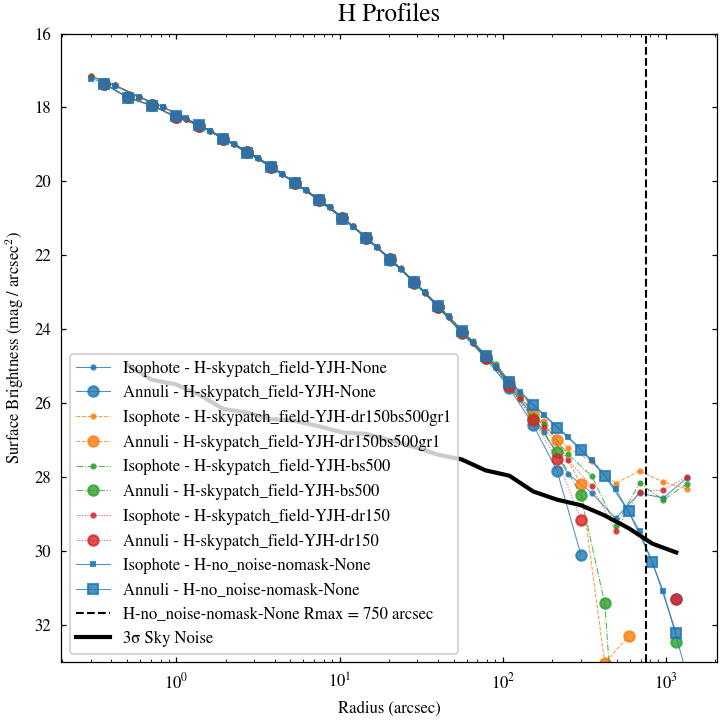

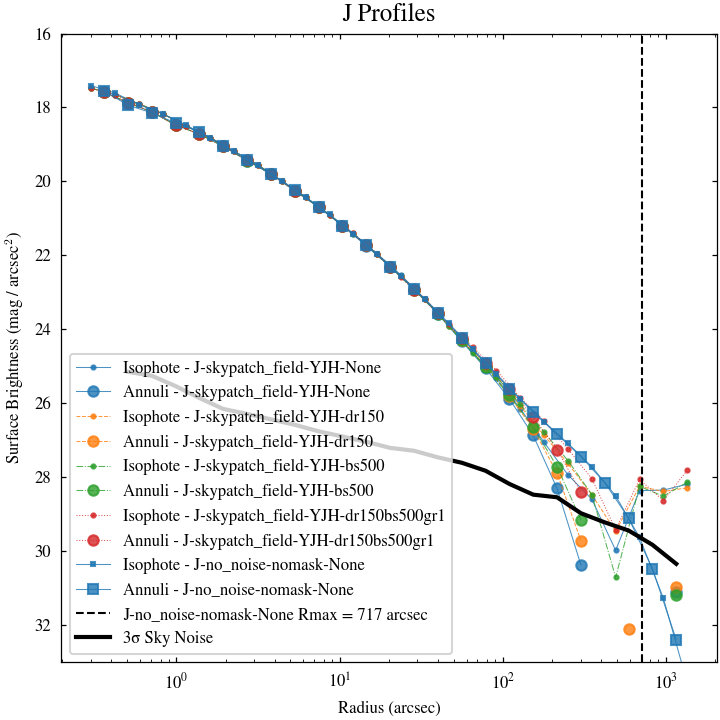

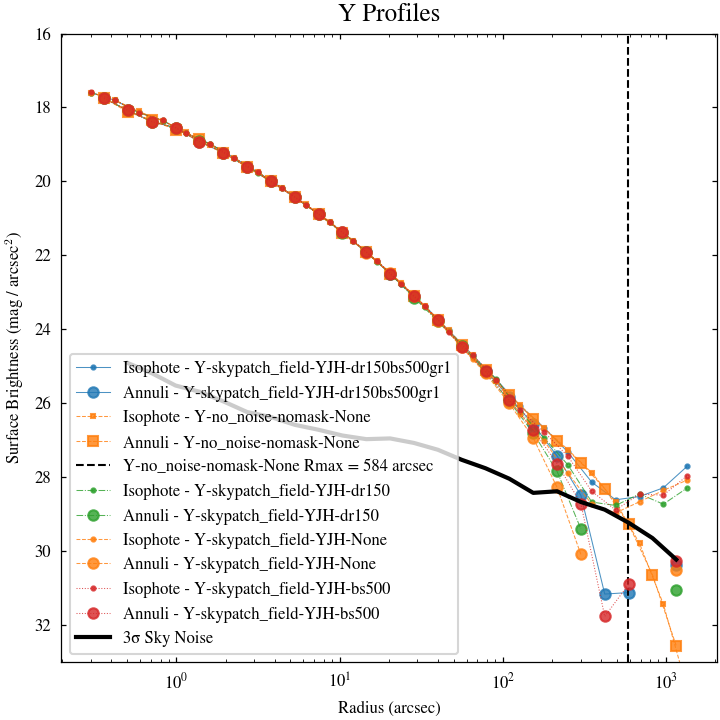

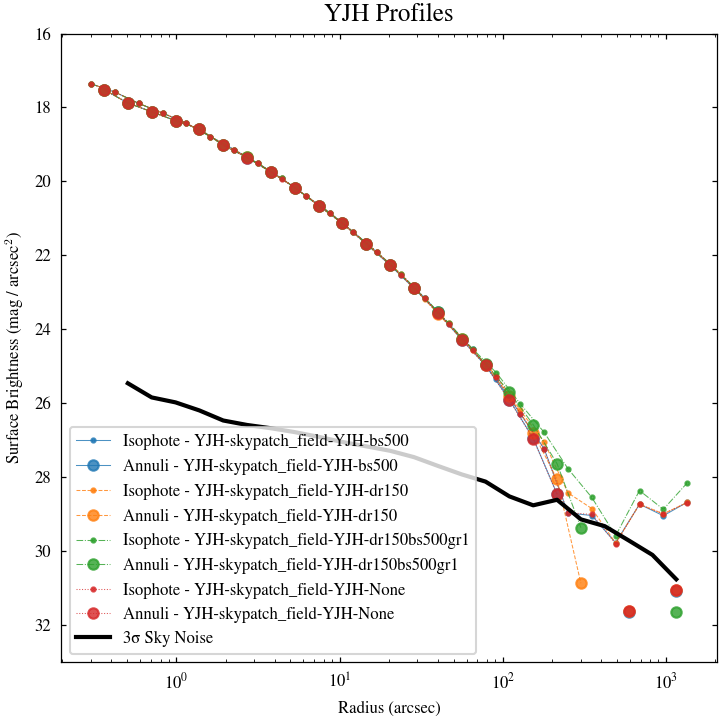

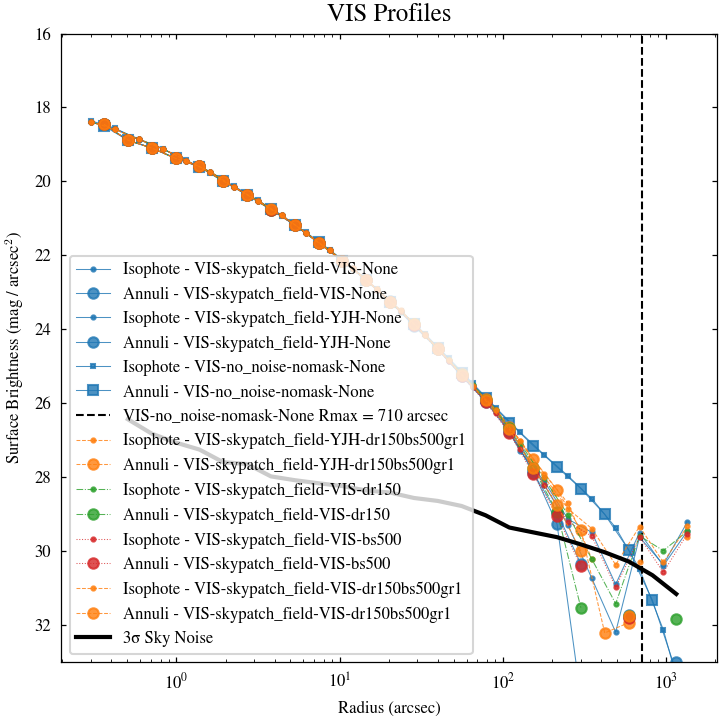

In [164]:


# noise profiles
noise_file_dir= Path('/home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/')
noise_profiles = {
    'H': pd.read_csv(noise_file_dir/'Skypatch_H_noise_measurements.csv'),
    'J': pd.read_csv(noise_file_dir/'Skypatch_J_noise_measurements.csv'),
    'Y': pd.read_csv(noise_file_dir/'Skypatch_Y_noise_measurements.csv'),
    'YJH': pd.read_csv(noise_file_dir/'Skypatch_YJH_noise_measurements.csv'),
    'VIS': pd.read_csv(noise_file_dir/'Skypatch_VIS_noise_measurements.csv'),
}

# profile sets
all_profiles = {
    'H': h_profiles,
    'J': j_profiles,
    'Y': y_profiles,
    'YJH': yjh_profiles,
    'VIS': vis_profiles,
}

# dictionaries for labels
all_dicts = {
    'H': profile_dicts['h'],
    'J': profile_dicts['j'],
    'Y': profile_dicts['y'],
    'YJH': profile_dicts['yjh'],
    'VIS': profile_dicts['vis'],
}

for band in ['H', 'J', 'Y', 'YJH', 'VIS']:
    profiles = all_profiles[band]
    labels = list(all_dicts[band].keys())
    noise_df = noise_profiles[band]

    style_dict = generate_style_dict_from_labels(
        labels=labels,
        color_by='mask_prefix',
        linestyle_by='mask_prefix',
        marker_by='prefix',
        label_format="{filter}-{prefix}-{mask_filter}-{mask_prefix}",
    )

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    plot_sb_profiles(
        profiles=profiles,
        style_dict=style_dict,
        specific_labels=labels,
        rad_output_unit='arcsec',
        ax=ax,
        fluxtype='mag',
        ylog=False,
        noise_profile=noise_df,
        extract_rmax=True,
        extract_rmax_labels=[
            f'{cluster_id}_{band}_no_noise_nomask_{band}'
        ]
    )

    # Noise profile in mag
    noise = 23.9 - 2.5 * np.log10(3 * noise_df['MAD_Median_Clipped_Flux'])
    ax.plot(noise_df['SMA_annulus_centre_arcsec'], noise, c='k', lw=2, label='3σ Sky Noise')

    ax.set_title(f"{band} Profiles", fontsize=12)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()



# Displaying VIS profiles with noise

/home/ppztk1/anaconda3/envs/icl/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ppztk1/anaconda3/envs/icl/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


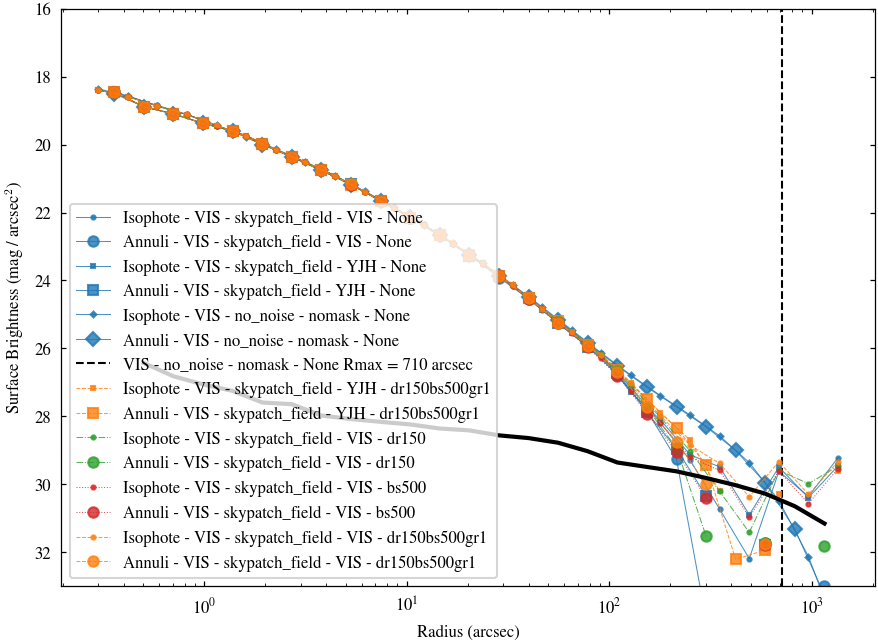

In [165]:
vis_noise_prof = pd.read_csv('/home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/Skypatch_VIS_noise_measurements.csv')
band = 'VIS'
labels = list(profile_dicts['vis'].keys())
style_dict = generate_style_dict_from_labels(
    labels = labels,
    color_by='mask_prefix',
    linestyle_by='mask_prefix',
    marker_by='mask_filter',
    label_format="{filter} - {prefix} - {mask_filter} - {mask_prefix}",
)

fig, ax=plt.subplots(1,1,figsize=(7,5))


plot_sb_profiles(
    profiles=vis_profiles,
    style_dict=style_dict,
    specific_labels=labels,
    rad_output_unit='arcsec',
    ax=ax,
    fluxtype='mag',
    ylog=False,
    noise_profile=vis_noise_prof,
    extract_rmax=True,
    extract_rmax_labels=[
    f'{cluster_id}_{band}_no_noise_nomask_{band}'
        ]
    
)
noise = 23.9 -2.5*np.log10(3*(vis_noise_prof['MAD_Median_Clipped_Flux']))
plt.plot(vis_noise_prof['SMA_annulus_centre_arcsec'], noise, c='k', lw=2)
plt.legend(fontsize=8)


# The shape profiles of different runs

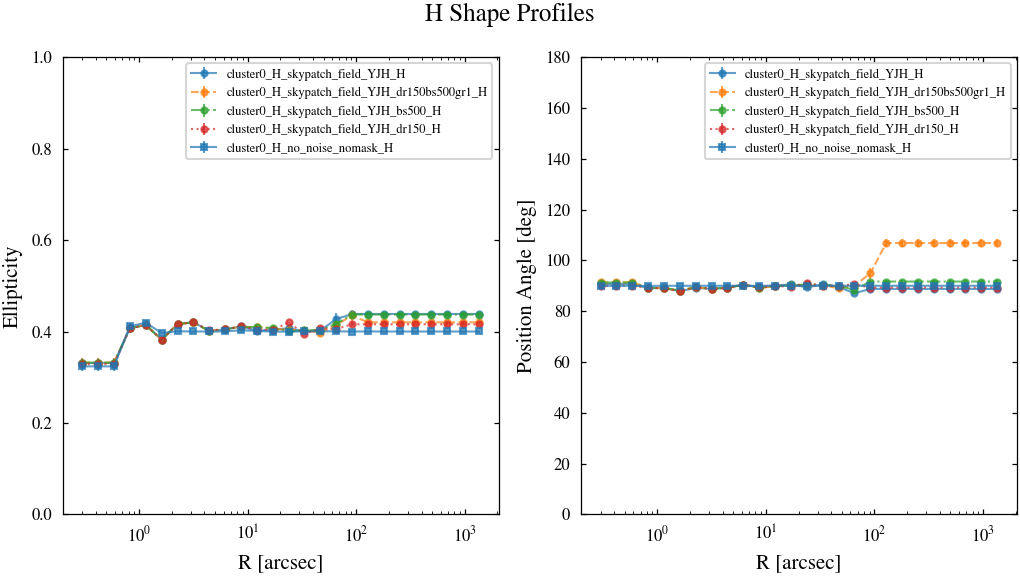

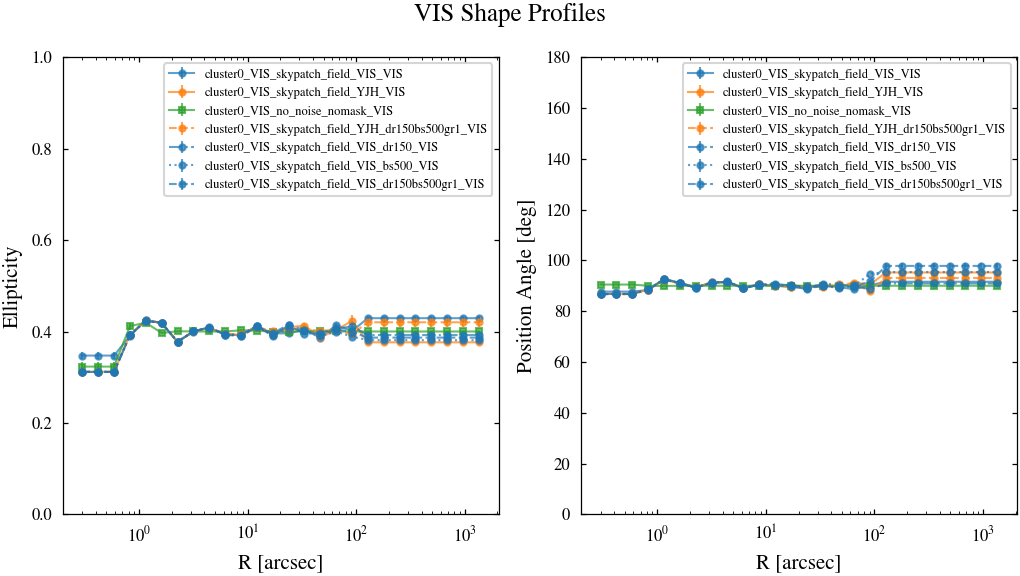

In [159]:
plot_shape_profiles(
    profiles=all_profiles['H'],
    label_dict=all_dicts['H'],
    band='H',
    color_by='mask_prefix',
    linestyle_by='mask_prefix',
    marker_by='prefix'
)

plot_shape_profiles(
    profiles=all_profiles['VIS'],
    label_dict=all_dicts['VIS'],
    band='VIS',
    color_by='mask_filter',
    linestyle_by='mask_prefix',
    marker_by='prefix'
)



/tmp/ipykernel_2316629/869531798.py:232: RuntimeWarning: invalid value encountered in divide
  residual_fraction = (ref_flux - cmp_flux) / ref_flux


750.127708000831


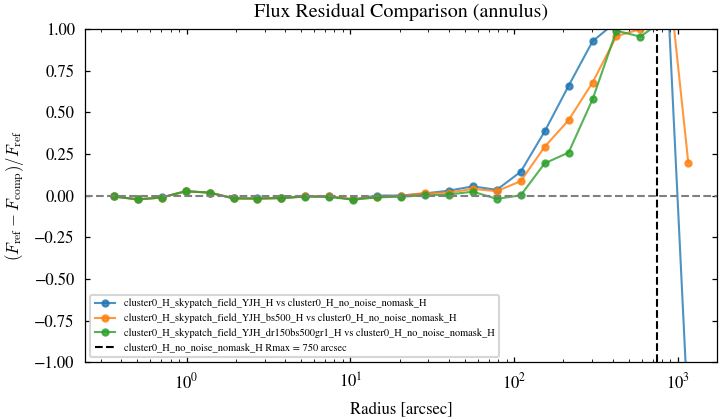

709.945583152015


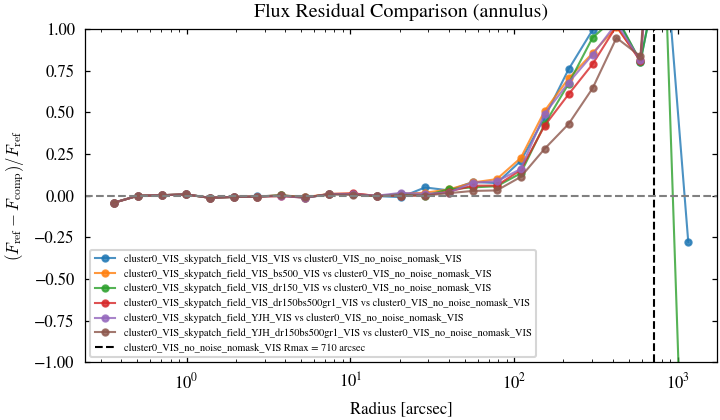

In [160]:
reference_key = 'cluster0_H_no_noise_nomask_H'
compare_keys = [
    'cluster0_H_skypatch_field_YJH_H',
    'cluster0_H_skypatch_field_YJH_bs500_H',
    'cluster0_H_skypatch_field_YJH_dr150bs500gr1_H',
]

plot_flux_residual_comparison(
    reference_label=reference_key,
    compare_labels=compare_keys,
    profiles=profile_dicts['h'],
    method="annulus",  
    ylims=[-1, 1],
    noise_profile=noise_profiles['H'],
    extract_rmax=True,
    legendloc="lower left"
)


reference_key = 'cluster0_VIS_no_noise_nomask_VIS'
compare_keys = [
    'cluster0_VIS_skypatch_field_VIS_VIS',
    'cluster0_VIS_skypatch_field_VIS_bs500_VIS',
    'cluster0_VIS_skypatch_field_VIS_dr150_VIS',
    'cluster0_VIS_skypatch_field_VIS_dr150bs500gr1_VIS',
    'cluster0_VIS_skypatch_field_YJH_VIS',
    'cluster0_VIS_skypatch_field_YJH_dr150bs500gr1_VIS',
]

plot_flux_residual_comparison(
    reference_label=reference_key,
    compare_labels=compare_keys,
    profiles=profile_dicts['vis'],
    method="annulus",  
    ylims=[-1, 1],
    noise_profile=noise_profiles['VIS'],
    extract_rmax=True,
    legendloc="lower left"
)